In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons

In [27]:
X, y = make_moons(
    n_samples=500,
    noise=0.2,
    random_state=42
)

In [30]:
df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y

df.head()

,feature_1,feature_2,target
0,0.830858,-0.334342,1
1,0.991710,0.879000,0
2,1.107245,-0.470344,1
3,-0.140899,1.033148,0
4,0.405592,1.328529,0


In [31]:
x = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

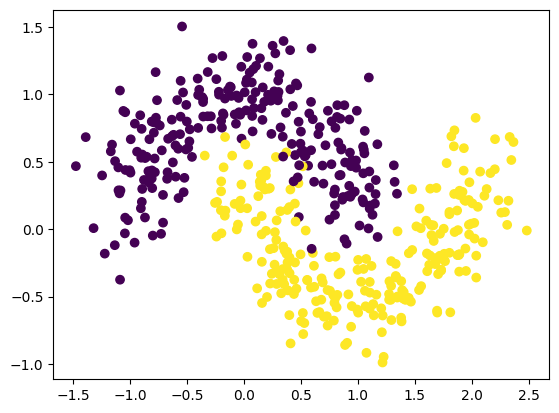

In [32]:
plt.scatter(x[:,0], x[:,1],c=y)

In [33]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()

In [34]:
clf.fit(x,y)

LogisticRegression()

<Axes: >

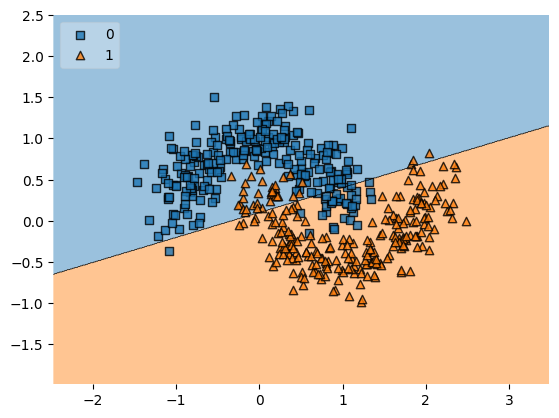

In [36]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x,y.astype('int'),clf, legend=2)

In [37]:
from sklearn.model_selection import cross_val_score
np.mean(cross_val_score(clf, x,y,scoring='accuracy',cv=10))

np.float64(0.8560000000000001)

In [43]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=3,include_bias=False)
X_trf = poly.fit_transform(X)

In [42]:
clf1 = LogisticRegression()
np.mean(cross_val_score(clf1,X_trf,y,scoring='accuracy',cv=10))

np.float64(0.96)

In [48]:
def plot_decision_boundary(x,y,degree=1):

  poly = PolynomialFeatures(degree=degree)
  x_trf = poly.fit_transform(x)

  clf = LogisticRegression()
  clf.fit(x_trf,y)

  accuracy = np.mean(cross_val_score(clf, x_trf, y, scoring='accuracy',cv=10))

  a= np.arange(start=x[:,0].min()-1, stop = x[:,0].max()+1, step=0.01)
  b =np.arange(start=x[:,1].min()-1, stop=x[:,1].max()+1, step=0.01)

  xx,yy = np.meshgrid(a,b)

  input_array = np.array([xx.ravel(),yy.ravel()]).T

  labels = clf.predict(poly.transform(input_array))

  plt.contourf(xx,yy,labels.reshape(xx.shape),alpha=0.5)
  plt.scatter(x[:,0],x[:,1],c=y)
  plt.title('degree = {}, accuracy is {}'.format(degree, np.round(accuracy,4)))

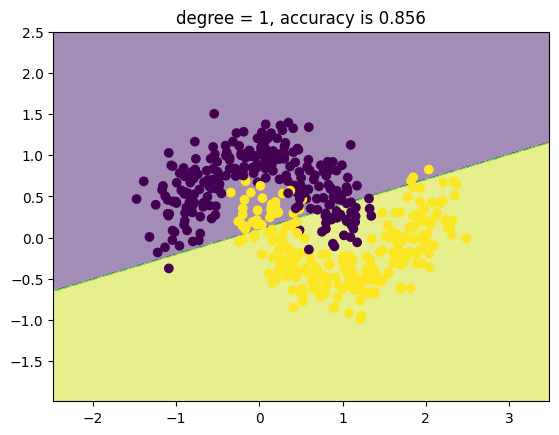

In [49]:
plot_decision_boundary(x,y)

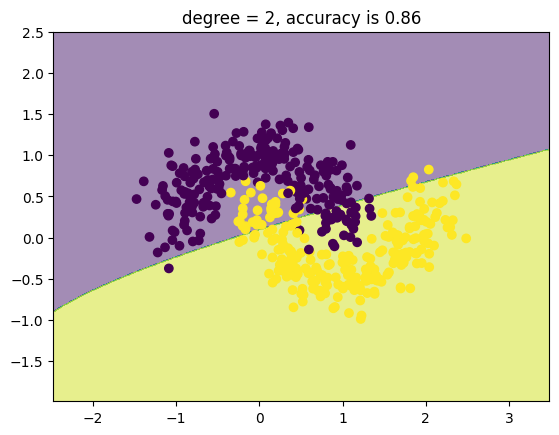

In [50]:
plot_decision_boundary(x,y,degree=2)

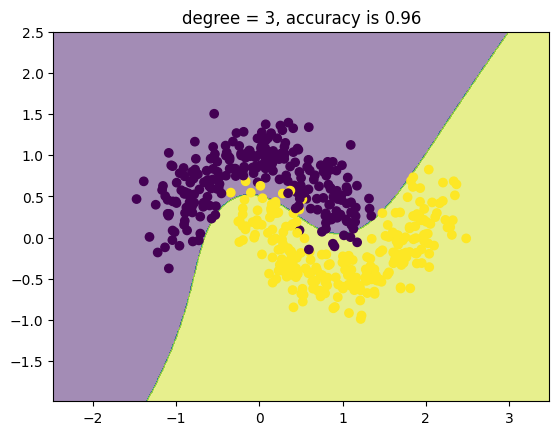

In [51]:
plot_decision_boundary(x,y,degree=3)

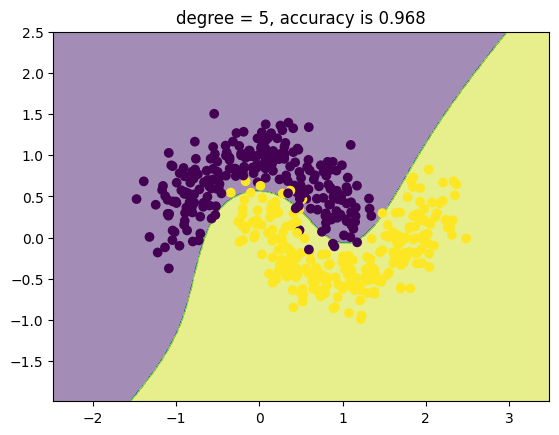

In [52]:
plot_decision_boundary(x,y,degree=5)